### Student Habits Analysis

#### Background Story

You have been hired by JAMB to analyze how students’ study habits affect their exam performance.

You are given a dataset containing information about students’ habits (study time, sleep, attendance, etc.) and their scores.

Your task is to explore the data, clean it, visualize patterns, and build a simple model that can predict student performance based on their habits.

#### Project Objectives

By the end of this project, you should be able to:

- Understand and explore a dataset
- Clean and prepare data for analysis
- Create meaningful visualizations
- Identify patterns and relationships
- Build a simple predictive model
- Draw conclusions from data

##### Step 1: Load Dataset

In [43]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# load the dataset
df = pd.read_csv("student_scores.csv")
# from "data/student_scores.csv"


### Data Loading
The dataset was loaded using Pandas.
And also matplotlib, seaborn, and numpy were all imported for if the need arises
And also the csv file was loaded also.

In [29]:
# display some rows
df.head()

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


 The first five rows were displayed to verify that the data was imported correctly using the above code

In [30]:
# check the shape
df.shape

(5000, 17)

As we can see from the above code output the dataset contains 5000 student records and 17 variables describing student characteristics, study habits, and examination performance or scores

##### Step 2: EDA

- Check column names and data types
- Identify missing values
- Look at basic statistics
- Understand what each feature represents

In [31]:
# code here. Use as many cells as you need.

# check the columns names and
df.columns

# check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   JAMB_Score                    5000 non-null   int64  
 1   Study_Hours_Per_Week          5000 non-null   int64  
 2   Attendance_Rate               5000 non-null   int64  
 3   Teacher_Quality               5000 non-null   int64  
 4   Distance_To_School            5000 non-null   float64
 5   School_Type                   5000 non-null   str    
 6   School_Location               5000 non-null   str    
 7   Extra_Tutorials               5000 non-null   str    
 8   Access_To_Learning_Materials  5000 non-null   str    
 9   Parent_Involvement            5000 non-null   str    
 10  IT_Knowledge                  5000 non-null   str    
 11  Student_ID                    5000 non-null   int64  
 12  Age                           5000 non-null   int64  
 13  Gender        

The dataset contains both numerical and categorical data variables. Numerical variable describe measurable(int and float data types) quantities such as study hours and atttendance rate, while categorical data(mainly string) describes student characteristics such as gender, school type and socieconomic status.

In [32]:
# identify missing values
df.isnull().sum()

JAMB_Score                        0
Study_Hours_Per_Week              0
Attendance_Rate                   0
Teacher_Quality                   0
Distance_To_School                0
School_Type                       0
School_Location                   0
Extra_Tutorials                   0
Access_To_Learning_Materials      0
Parent_Involvement                0
IT_Knowledge                      0
Student_ID                        0
Age                               0
Gender                            0
Socioeconomic_Status              0
Parent_Education_Level          891
Assignments_Completed             0
dtype: int64

As observed from the above code output all columns are 0 except for Parent_Education_Level colums with 891, which implies that all columns are filled up except that of Parent_Education_Level which has 891 missing values.

#### Calculate percentage of missing values

In [9]:
#calculate missing percentage
missing_percentage = (891 / 5000) * 100
missing_percentage

17.82

The variable Parent_Education_Level contains 891 missing values out of 5000, which is approximately 17.82% of the dataset, since the percentage is not that high we can handle it rather than deleting the entire column

#### Check for duplicates

In [ ]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

From above the dataset was checked of duplicates and so no duplicates were found, which suggest that each student's record  is unique so no removal is required

#### Basic Stistics

In [12]:
df.describe(include='all')

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000,5000,5000,5000,5000,5000.000000,5000.000000,5000,5000,4109,5000.000000
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,3,3,NaN,NaN,2,3,3,NaN
top,NaN,NaN,NaN,NaN,NaN,Public,Urban,Yes,Yes,Medium,Medium,NaN,NaN,Female,Medium,Secondary,NaN
freq,NaN,NaN,NaN,NaN,NaN,3735,2834,2721,3346,2012,1970,NaN,NaN,2530,1967,1556,NaN
mean,174.074600,19.521200,84.235200,2.521400,10.005460,NaN,NaN,NaN,NaN,NaN,NaN,2500.500000,18.445800,NaN,NaN,NaN,1.804600
std,47.616477,9.634569,9.485688,0.985564,4.820221,NaN,NaN,NaN,NaN,NaN,NaN,1443.520003,2.301504,NaN,NaN,NaN,0.992076
min,100.000000,0.000000,50.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,15.000000,NaN,NaN,NaN,1.000000
25%,135.000000,13.000000,78.000000,2.000000,6.600000,NaN,NaN,NaN,NaN,NaN,NaN,1250.750000,16.000000,NaN,NaN,NaN,1.000000
50%,170.000000,19.000000,84.000000,2.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2500.500000,18.000000,NaN,NaN,NaN,1.000000
75%,209.000000,26.000000,91.000000,3.000000,13.400000,NaN,NaN,NaN,NaN,NaN,NaN,3750.250000,20.000000,NaN,NaN,NaN,2.000000


Looking at the statistics and going through it, it might come in handy later

**Observations**:

##### Step 3: Clean the Data

- Handle missing values
- Fix incorrect data types
- Remove duplicates if any
- Rename columns if necessary

#### Handle missing values

In [ ]:
# code here. Use as many cells as you need.
# check for the valuse of the column
df['Parent_Education_Level'].value_counts(dropna=False)

Parent_Education_Level
Secondary    1556
Primary      1335
Tertiary     1218
NaN           891
Name: count, dtype: int64

From the above we can see that the values for the columns includes only Secondary, Primary and Tertiairy and empty ones.
To handle we can go about two ways either by filling out the missing values with the most occuring value or introduce a new value e.g 'Unknown' to cover up for it. But the disadvantage of us using the mode is that, it makes the dataset bias, so i think it will be better for us to use the new variable

In [44]:
#handling the missing values
df['Parent_Education_Level'] = df['Parent_Education_Level'].fillna('Unknown')

In [45]:
# check whether it has worked
df['Parent_Education_Level'].isnull().sum()
# As we can see it should output zero which means it has worked

np.int64(0)

In [16]:
# check the data types
df.dtypes

JAMB_Score                        int64
Study_Hours_Per_Week              int64
Attendance_Rate                   int64
Teacher_Quality                   int64
Distance_To_School              float64
School_Type                         str
School_Location                     str
Extra_Tutorials                     str
Access_To_Learning_Materials        str
Parent_Involvement                  str
IT_Knowledge                        str
Student_ID                        int64
Age                               int64
Gender                              str
Socioeconomic_Status                str
Parent_Education_Level              str
Assignments_Completed             int64
dtype: object

#### Remove column
Looking at the complete dataset and going through each variable, I think the only column that will not be of importance is the Student_ID, why; becuse it only shows the the unique identity of the student but doesn't affect the ability and performance of the student in any way so i think it won't be of importance in the predictive sense

In [46]:
# Dropping the Student_ID column
df.drop('Student_ID', axis=1, inplace=True)
# the axis=1 is used to specify the direction in which pandas should look, axis=0 signifies rows while axis=1 signifies column, and without specifying by default it will look at rows and will throw an error if it can't find one.
# the inplace=True dictates how the operation is applied to your computer's memory. By default inplace=False it doesn't alter your original dataset rather creates a copy of your data with alteration added and sspits it out, While for inplace=True you are telling pandas to Modify the Original dataset directly inplace.

**Why did you make these changes?**:

The changes made are basically two, one is that we filled out the empty variables with a new variable 'Unknown',and it was used instead of the mean or mode to avoid makin assumptions, and allows us to analyze whether missing parental education has any relationship with the scores and also preserves the information that the value was missing, Two the Student_ID column was dropped because it doesn't affect exam performance and does not describe academic ability perhaps only used to uniquely to identify students

In [ ]:
# Check dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   JAMB_Score                    5000 non-null   int64  
 1   Study_Hours_Per_Week          5000 non-null   int64  
 2   Attendance_Rate               5000 non-null   int64  
 3   Teacher_Quality               5000 non-null   int64  
 4   Distance_To_School            5000 non-null   float64
 5   School_Type                   5000 non-null   str    
 6   School_Location               5000 non-null   str    
 7   Extra_Tutorials               5000 non-null   str    
 8   Access_To_Learning_Materials  5000 non-null   str    
 9   Parent_Involvement            5000 non-null   str    
 10  IT_Knowledge                  5000 non-null   str    
 11  Age                           5000 non-null   int64  
 12  Gender                        5000 non-null   str    
 13  Socioeconomic_

From the above output, we can see that; 
No missing values remain, 
Student_ID id gone, 
Dataset has now 16 columns.

##### Step 4: Visualise the Data

- Show distribution of key variables
- Compare different groups
- Explore relationships between variables


#### Distribution of Key Variables
taking JAMB_Score as the most important key value; we look at it's distribution


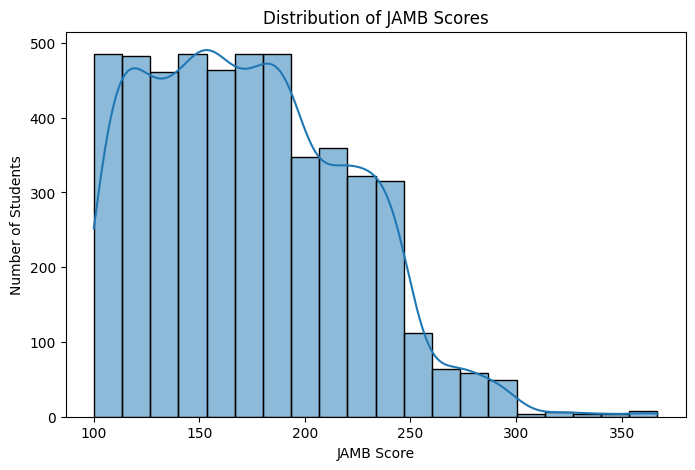

In [34]:
# code here. Use as many cells as you need.
# Distribution of JAMB_Scores
plt.figure(figsize=(8,5))
sns.histplot(df['JAMB_Score'], bins=20, kde=True)

plt.title('Distribution of JAMB Scores')
plt.xlabel('JAMB Score')
plt.ylabel('Number of Students')

plt.show()

Distribution of JAMB Scores

The distribution of JAMB scores shows that most students scored between 130 and 250 marks, with the highest concentration around 140–180 marks. The distribution is positively skewed, indicating that while most students achieved moderate scores, a smaller number of students obtained exceptionally high scores above 300. This suggests that very high performance is somehow uncommon in the dataset.

Study Hoours against JAMB Scores; 
- to answer the question of do student's who study moe tend to have higher JAMB Scores

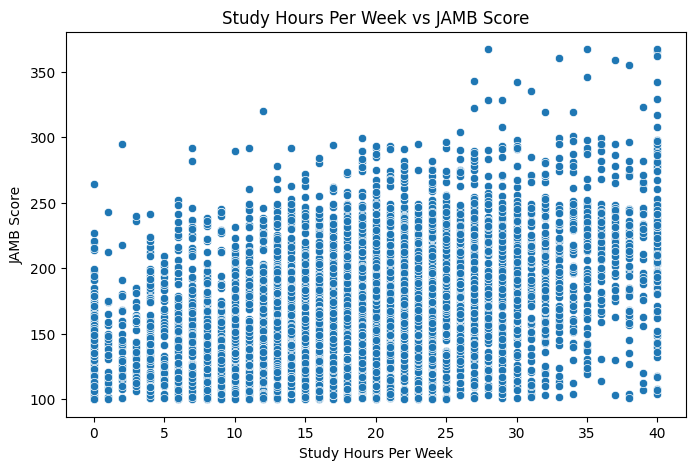

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Study_Hours_Per_Week',
    y='JAMB_Score',
    data=df
)

plt.title('Study Hours Per Week vs JAMB Score')
plt.xlabel('Study Hours Per Week')
plt.ylabel('JAMB Score')

plt.show()

Study Hours Per Week vs JAMB Scores

The satterplot above shows the relationship between Study Hours Per Week and JAMB Scores, student who dedicate more hours to studying generally achieve higher scores, but it alone doesn't explain why the students have higher scores, so we go on further and do more relationships

Attendance rate against JAMB Score
- Helps determine whether students who regularly attend school tend to have higher Scores

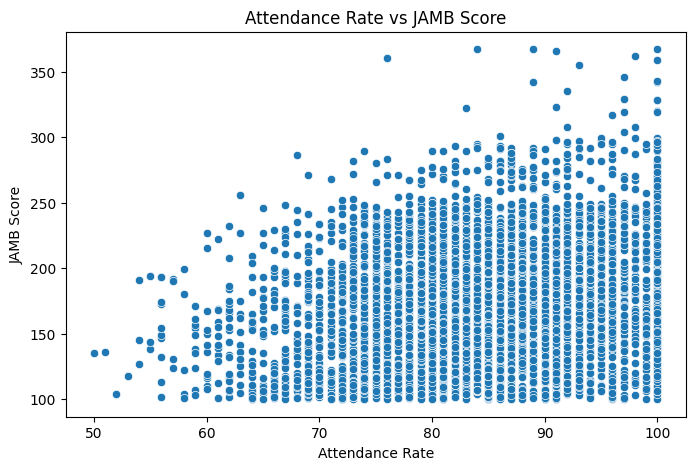

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Attendance_Rate',
    y='JAMB_Score',
    data=df
)

plt.title('Attendance Rate vs JAMB Score')
plt.xlabel('Attendance Rate')
plt.ylabel('JAMB Score')

plt.show()

Attendance Rate vs JAMB Score

The above scatter plot indicates a relationship between attendance rateand JAMB performance. Students with higher attendance rates generally achieve better examination scores. While students with lower attendance rates tend to perform less well. The highest-performing students are mostly found among those with attendance rates above 80%. However, attendance alone does not fully explain performance differences, we can go ahead and check other factors also.

Teacher Quality Against JAMB Score
- Shows whether teacher's quality do really affects the Students' Scores

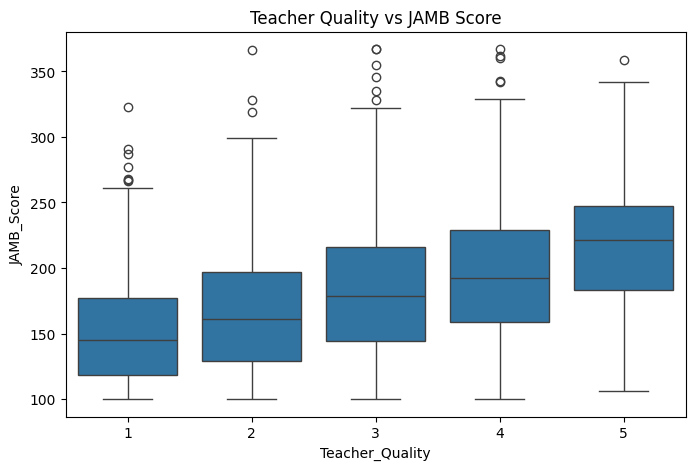

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Teacher_Quality',
    y='JAMB_Score',
    data=df
)

plt.title('Teacher Quality vs JAMB Score')

plt.show()

Teacher Quality vs JAMB Score

The boxplot above reveals a strong positive relationship between teacher quality and JAMB performance. As teacher quality increases from 1 to 5, the median examination score rises steadily. Students taught by higher-quality teachers generally achieve higher scores than those taught by lower-quality teachers. Although some exceptional students perform well regardless of teacher quality, the overall trend indicates that teacher effectiveness plays an important role in student success.

Gender and JAMB Score
- To compare Scores between Male and Female Candidates

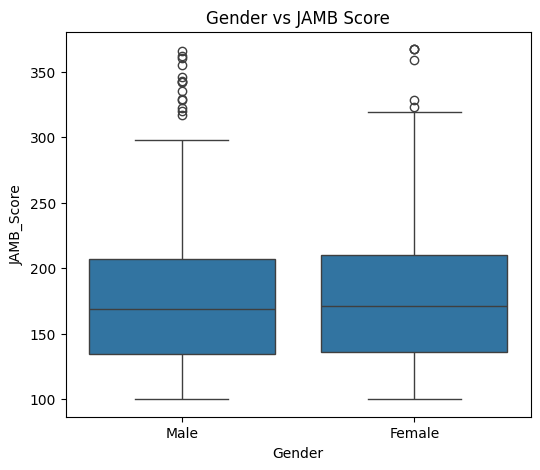

In [38]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='Gender',
    y='JAMB_Score',
    data=df
)

plt.title('Gender vs JAMB Score')

plt.show()

Gender vs JAMB Score

The boxplot above shows that male and female students have very similar JAMB score distributions. The median scores and score ranges for both groups are nearly alike, showiung that gender has little influence on examination performance in the dataset. This implies that academic success is more strongly associated with factors such as study habits, attendance, and teacher quality than with gender.

Correlation Heatmap
- we are just checking in relation to JAMB_Scores

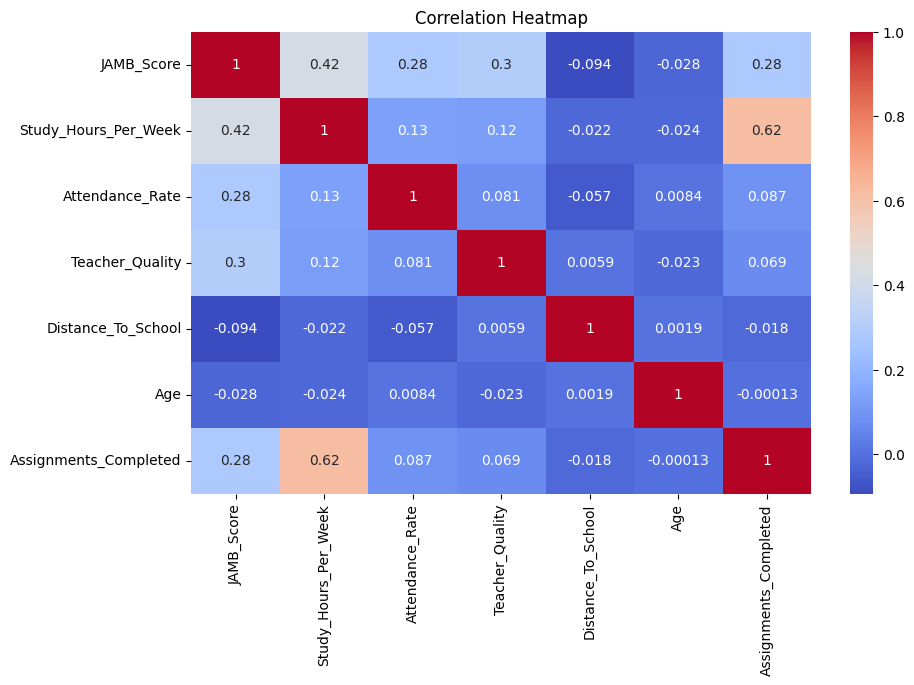

In [39]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

Correlation Analysis

The correlations with JAMB_Score are:

Variable	Correlation with JAMB Score

Study_Hours_Per_Week	0.42

Teacher_Quality	0.30

Attendance_Rate	0.28

Assignments_Completed	0.28

Distance_To_School	-0.094

Age	-0.028

Interpretation

1. Study Hours Per Week (0.42)

This is the strongest numerical predictor in the dataset.

A correlation of 0.42 indicates a moderate positive relationship.

This means:

Students who spend more time studying tend to achieve higher JAMB scores.

This confirms what we observed in the scatter plot.

2. Teacher Quality (0.30)

Teacher quality has a positive relationship with student performance.

This suggests:

Better teaching quality is associated with higher JAMB scores.

The boxplot showed this very clearly.

3. Attendance Rate (0.28)

Attendance also has a positive relationship with performance.

This indicates:

Students who attend school more regularly generally perform better.

4. Assignments Completed (0.28)

Students who complete more assignments tend to score higher.

This makes educational sense because assignments provide practice and reinforce learning.

5. Distance to School (-0.094)

This is a weak negative correlation.

Interpretation:

Students living farther from school tend to score slightly lower, but the effect is very small.

6. Age (-0.028)

This correlation is almost zero.

Interpretation:

Age appears to have little or no relationship with JAMB performance in this dataset.

Additional Insight

One interesting relationship is:

Variables	Correlation
Study_Hours_Per_Week & Assignments_Completed	0.62

This is fairly strong.

Interpretation:

Students who study more also tend to complete more assignments.

This relationship is logical and supports the reliability of the dataset.

Correlation Analysis

The correlation analysis revealed that Study Hours Per Week has the strongest positive relationship with JAMB score (r = 0.42), indicating that students who spend more time studying generally achieve higher examination scores. Teacher Quality (r = 0.30), Attendance Rate (r = 0.28), and Assignments Completed (r = 0.28) also show positive relationships with academic performance. Distance to School (-0.094) and Age (-0.028) exhibit very weak negative correlations, suggesting that they have little influence on examination outcomes. Overall, study habits and educational factors appear to be more important predictors of student success than demographic factors.

**Observations**:

##### Step 5: Feature Thinking (Before Modeling)

- Decide which variables might affect performance
- Select relevant features

Guide prompts:

- Which habits do you think influence scores most?
- Are any variables irrelevant?

#### Recommended Features
##### Numerical Features

- Study_Hours_Per_Week
- Attendance_Rate
- Teacher_Quality
- Assignments_Completed
- Distance_To_School
- Age

##### Categorical Features
- School_Type
- School_Location
- Extra_Tutorials
- Access_To_Learning_Materials
- Parent_Involvement
- IT_Knowledge
- Gender
- Socioeconomic_Status
- Parent_Education_Level

##### Target Variable Being
JAMB_Score

The selected features were chosen based on exploratory analysis and correlation results. Study Hours Per Week, Teacher Quality, Attendance Rate, and Assignments Completed showed the strongest relationships with JAMB score and were therefore considered important predictors. Additional demographic and educational variables were also retained because they may contribute useful information when combined with other factors. The target variable for prediction is JAMB Score.
Though I think even if we are to select irrelevant variable will be Age and Gender, but i still think that it still will be of small importance also.

##### Step 6: Build the model

- Split data into training and testing sets
- Train a simple model 
- Make predictions

##### Separate Features and Target

In [49]:
# code here. Use as many cells as you need.
X = df.drop('JAMB_Score', axis=1)
y = df['JAMB_Score']


##### One-Hot Encode Categorical Variables

In [50]:
X = pd.get_dummies(X, drop_first=True)

Check transformed Dataset

In [53]:
X.head()

,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,Age,Assignments_Completed,School_Type_Public,School_Location_Urban,Extra_Tutorials_Yes,Access_To_Learning_Materials_Yes,Parent_Involvement_Low,Parent_Involvement_Medium,IT_Knowledge_Low,IT_Knowledge_Medium,Gender_Male,Socioeconomic_Status_Low,Socioeconomic_Status_Medium,Parent_Education_Level_Secondary,Parent_Education_Level_Tertiary,Parent_Education_Level_Unknown
0,22,78,4,12.4,17,2,True,True,True,True,False,False,False,True,True,True,False,False,True,False
1,14,88,4,2.7,15,1,True,False,False,True,False,False,False,False,True,False,False,False,False,True
2,29,87,2,9.6,20,2,True,False,True,True,False,False,False,True,False,False,False,False,True,False
3,29,99,2,2.6,22,1,True,True,False,True,False,True,False,False,False,False,True,False,True,False
4,12,98,3,8.8,22,1,True,True,False,True,False,True,False,True,False,False,True,False,True,False


In [52]:
X.shape

(5000, 20)

Encoding Categorical Variables

Machine learning algorithms require numerical inputs. Therefore, categorical variables were transformed using One-Hot Encoding. This process converts each category into a binary indicator variable while avoiding redundant information through the use of drop_first=True.

Split Data into Training and Testing Sets

We'll use 80% of the data for training and 20% for testing.

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
# Check the sizes;
print(X_train.shape)
print(X_test.shape)

(4000, 20)
(1000, 20)


Train-Test Split

The dataset was divided into training and testing subsets. Eighty percent of the data was used to train the model, while twenty percent was reserved for evaluating its performance on unseen data.

##### Train the Linear Regression Model

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Make Predictions

In [57]:
predictions = model.predict(X_test)

##### Step 7: Evaluate the Model

- Compare predictions with actual values
- Use simple metrics (e.g., error, accuracy depending on task)

Guide prompts:

- Is the model reliable?
- Where does it fail?


In [58]:
# code here. Use as many cells as you need.
# Evaluate the model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 31.42040074190167
RMSE: 39.079801550459806
R²  : 0.3671809164160805


Model Evaluation

The Linear Regression model achieved a Mean Absolute Error (MAE) of 31.42 and a Root Mean Squared Error (RMSE) of 39.08. This indicates that the model's predictions differ from actual JAMB scores by approximately 31 marks on average.

The model obtained an R² score of 0.367, meaning that approximately 36.7% of the variation in JAMB scores can be explained by the features included in the dataset. While the model captures several important factors affecting academic performance, a substantial proportion of score variation remains unexplained, suggesting that additional variables may be required to improve predictive accuracy.

Is the Model reliable?

Strengths

The model successfully detected meaningful relationships between:

- Study hours
- Attendance
- Teacher quality
- Assignment completion
- Other student characteristics

and JAMB scores.

Limitations

The R² value shows that a large portion of student performance remains unexplained.

Possible missing factors include:

- Student motivation
- Intelligence/aptitude
- Family support
- Health conditions
- Peer influence
- Access to internet resources

##### Step 8: Conclusions

- Summarize key findings
- State which habits impact performance
- Suggest recommendations

Conclusion

This project investigated the relationship between student habits and JAMB examination performance using a dataset containing 5,000 student records.

Exploratory data analysis revealed that Study Hours Per Week, Teacher Quality, Attendance Rate, and Assignments Completed were positively associated with JAMB scores. Gender and Age showed little influence on performance, while Distance to School exhibited a weak negative relationship.

A Linear Regression model was developed to predict JAMB scores based on student characteristics and study habits. The model achieved an R² score of 0.367, indicating that the selected variables explain a meaningful portion of student performance, although additional factors not included in the dataset likely contribute to examination outcomes.

Overall, the findings suggest that consistent study habits, regular attendance, quality teaching, and assignment completion are important contributors to academic success.

#### Advanced Analyis
##### Random Forest Analysis
A Random Forest is often more powerful than Linear Regression because it can capture complex, non-linear relationships between variables.

In [59]:
# Import Model
from sklearn.ensemble import RandomForestRegressor

In [60]:
# Create the Model
#start with 100 trees
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
# What these parameters mean
# n_estimators=100
# Builds 100 decision trees.
# random_state=42
# Ensures reproducible results.

In [61]:
# Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [62]:
# make predictions
rf_predictions = rf_model.predict(X_test)

In [63]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
MAE : 33.4763
RMSE: 41.004628043673314
R²  : 0.30330832414141673


In [64]:
# compare Models
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R²': [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,31.420401,39.079802,0.367181
1,Random Forest,33.476300,41.004628,0.303308


In [65]:
# Feature Importance
#One advantage of Random Forest is that it tells us which variables are most important
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Study_Hours_Per_Week,0.254898
3,Distance_To_School,0.154286
1,Attendance_Rate,0.154058
2,Teacher_Quality,0.076024
4,Age,0.069224
5,Assignments_Completed,0.037383
15,Socioeconomic_Status_Low,0.021718
10,Parent_Involvement_Low,0.019391
7,School_Location_Urban,0.019334
8,Extra_Tutorials_Yes,0.019197


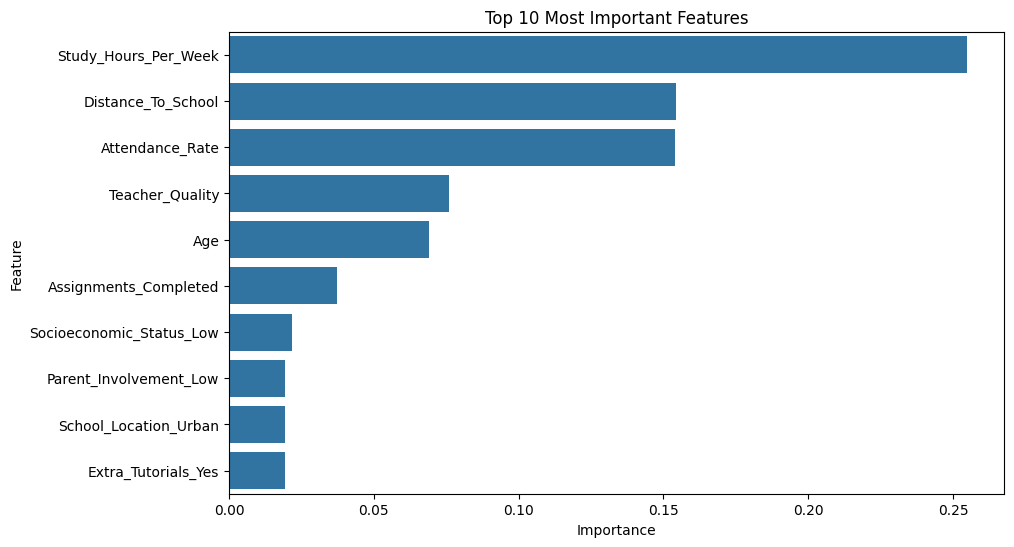

In [66]:
# Visualize Feature Importance
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Most Important Features')
plt.show()

Advanced Analysis: Random Forest Regression

To improve predictive performance, a Random Forest Regressor was trained and evaluated alongside the Linear Regression model. Random Forest is an ensemble learning algorithm that combines multiple decision trees to capture complex relationships between variables.

The performance metrics of both models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. The model with the higher R² and lower error values was considered the better predictor of JAMB scores.

Additionally, feature importance analysis was conducted to identify the variables that contributed most strongly to prediction accuracy

Which Model Performed Better?

Surprisingly, the Linear Regression model performed better than the Random Forest model.

Evidence
MAE
Linear Regression: 31.42
Random Forest:     33.48

Lower is better.

Linear Regression wins.

RMSE
Linear Regression: 39.08
Random Forest:     41.00

Lower is better.

Linear Regression wins.

R²
Linear Regression: 0.367
Random Forest:     0.303

Higher is better.

 Linear Regression wins.

Why Did This Happen?

Many students assume Random Forest always performs better, but that's not true.

Possible reasons:

1. Relationships May Be Mostly Linear

The data appears to show fairly direct relationships:

More study hours → higher scores
Better attendance → higher scores
Better teacher quality → higher scores

Linear Regression is very effective when relationships are approximately linear.

2. Dataset Structure

The variables in your dataset may already explain performance in a relatively straightforward way.

In such cases, Random Forest may not gain much advantage.

3. Educational Data Often Contains Noise

A large portion of performance variation is not captured in the dataset.

Remember:

R² ≈ 0.37

This means over 60% of score variation is still unexplained.

No model can learn information that isn't present in the data.

Excellent Discussion Point for Your Report

Many lecturers love seeing this kind of analysis:

Although Random Forest is generally considered a more sophisticated machine learning algorithm, it did not outperform Linear Regression on this dataset. This suggests that the relationships between the predictor variables and JAMB scores are relatively linear in nature. Consequently, Linear Regression provided the most accurate predictions among the models tested.


Recommendations

Based on the findings of this study:

1. Students should increase their weekly study hours, as study time showed the strongest relationship with JAMB performance.
2. Schools should encourage regular attendance since higher attendance rates were associated with improved examination scores.
3. Educational institutions should invest in teacher development programs because teacher quality was positively linked to student achievement.
4. Students should be encouraged to complete assignments consistently, as assignment completion was associated with better academic outcomes.
5. Future studies should include additional variables such as motivation, mental health, learning styles, internet access, and family support to improve predictive accuracy.

Final Project Summary
Dataset
5,000 students
16 cleaned variables
Data Cleaning
Removed Student_ID
Handled missing values in Parent_Education_Level
Verified no duplicate records
Key Findings
Study Hours Per Week had the strongest correlation with JAMB score (0.42)
Teacher Quality showed a strong positive effect
Attendance Rate positively influenced performance
Assignment Completion positively influenced performance
Gender and Age had little impact
Models Tested
Linear Regression
MAE = 31.42
RMSE = 39.08
R² = 0.367
Random Forest
MAE = 33.48
RMSE = 41.00
R² = 0.303
Best Model

Linear Regression

It achieved the highest R² score and the lowest prediction errors.